## EXPLORTARY DATA ANALYSIS (ON CLEANED DATA)

## Importing Required Libraries

In [1]:
# DATA HANDLING
import pandas as pd
import numpy as np

# DATA VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

##  Loading the Dataset

In [2]:
# ===Load Data===
pd.set_option('display.max_columns', None)
data=pd.read_csv('Cleaned_Data_Emp.csv')

### CHART - 1 

[Text(0.5, 1.0, 'Relation between Salary hike & Performance rating')]

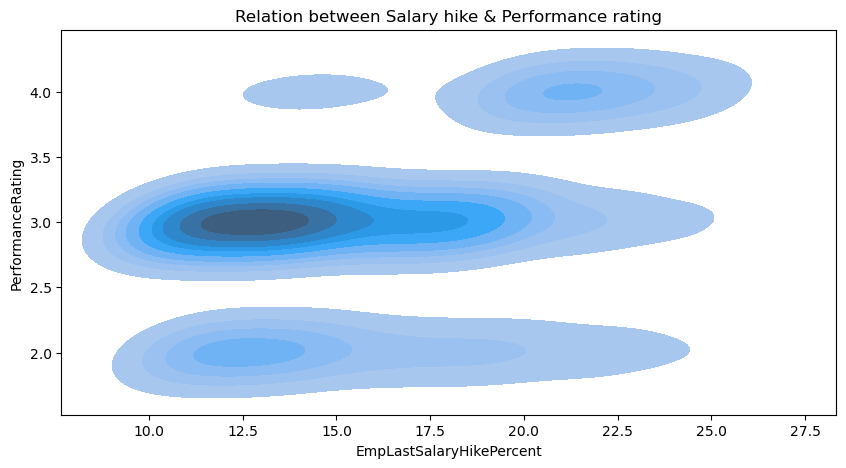

In [3]:
# ========== Analysis of performance rating as per Salary hike ===============

plt.subplots(figsize=(10, 5))
kde = sns.kdeplot(data=data, x="EmpLastSalaryHikePercent", y ='PerformanceRating',multiple="stack",
                  palette = 'viridis', fill = True, linewidth = 0)
kde.set(title = 'Relation between Salary hike & Performance rating')

Now, Employees with higher salary hikes tend to have higher performance ratings, indicating a positive relationship between salary increment and performance.

### CHART - 2

Text(0.5, 1.0, 'Relationship between Environment Satisfaction and Performance Rating')

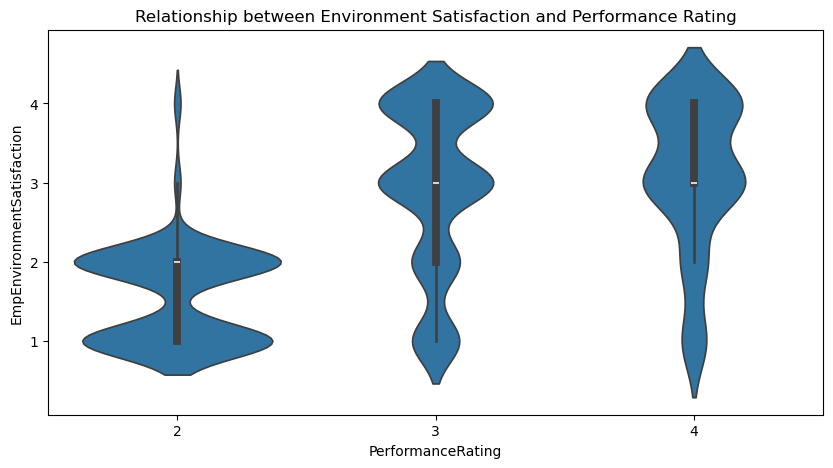

In [4]:
# ========== Relationship between Environment Satisfaction and Performance Rating ===============
plt.subplots(figsize=(10, 5))
sns.violinplot(x='PerformanceRating', y='EmpEnvironmentSatisfaction', data=data)
plt.title('Relationship between Environment Satisfaction and Performance Rating')

Now, Employees with higher performance ratings tend to have higher levels of environment satisfaction.

### CHART - 3

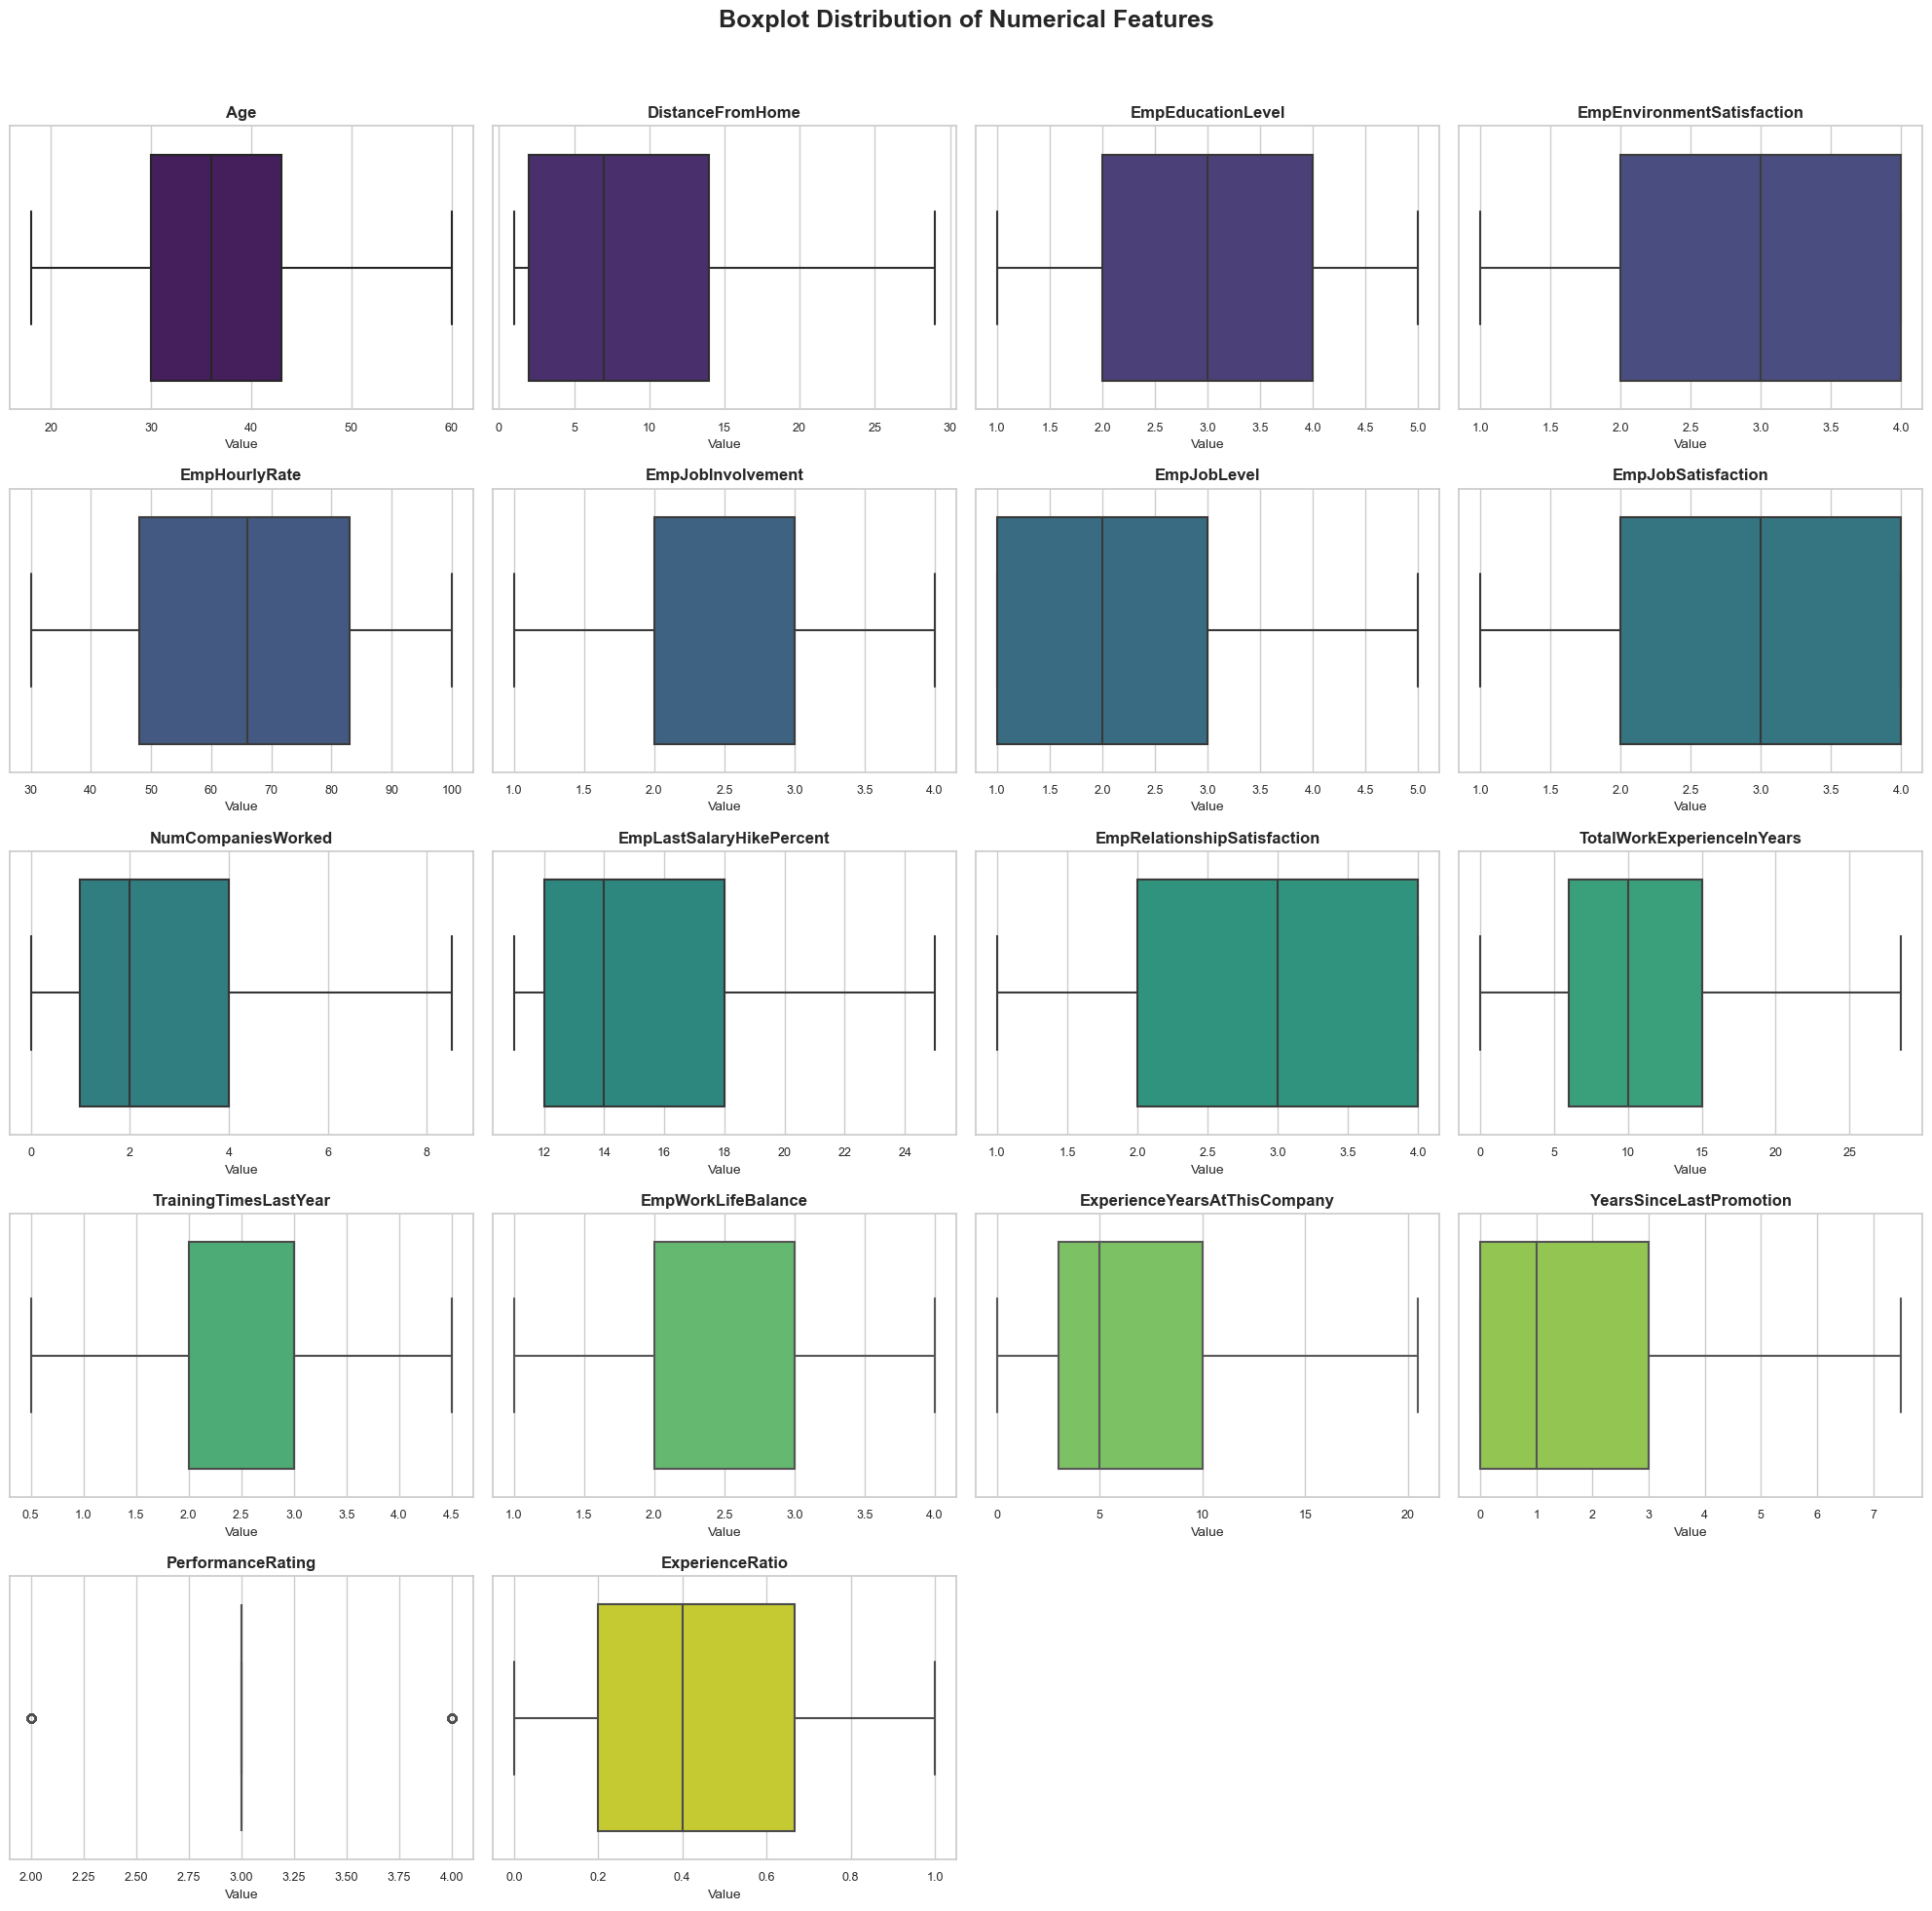

In [5]:
# Style
sns.set(style="whitegrid")

# Select numeric columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Color palette
colors = sns.color_palette("viridis", len(numeric_cols))

#  Choose number of plots per row
n_cols = 4   # change to 5 if needed
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i+1)

    sns.boxplot(
        x=data[col],   # horizontal
        color=colors[i],
        linewidth=1.5
    )

    # Titles
    plt.title(col, fontsize=12, fontweight='bold')

    #  Make axis labels visible
    plt.xlabel("Value", fontsize=10)
    plt.ylabel("")

    #  Improve tick visibility
    plt.xticks(fontsize=9)

# Main title
plt.suptitle(
    "Boxplot Distribution of Numerical Features",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Now, The preprocessed data shows well-balanced distributions with reduced outliers, indicating effective data cleaning and readiness for reliable model training.

### CHART - 4

In [8]:
# ===================== The temporary label encoding for analysis the correlation =======================
from sklearn.preprocessing import LabelEncoder
temp_data = data.copy()
cat_cols=['Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime',
       'Attrition']
encoder = LabelEncoder()
# Loop through the columns in cat_cols1 and apply LabelEncoder
for col in cat_cols:
    temp_data[col] = encoder.fit_transform(temp_data[col])

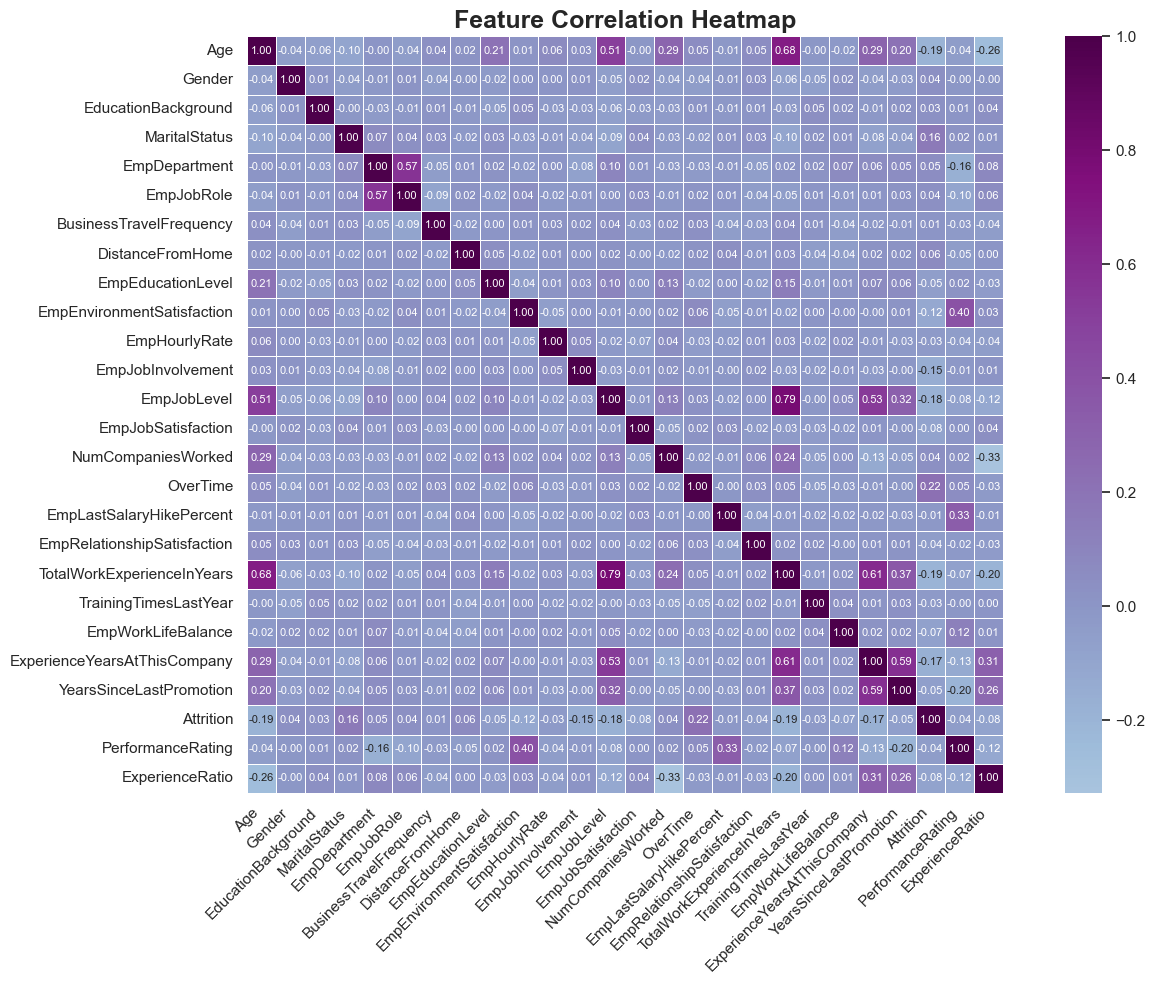

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = temp_data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="BuPu",
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    square=True,
    annot_kws={"size":8}
)

plt.title("Feature Correlation Heatmap", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()